# Symmetric Blended Log-Normal

This notebook illustrates a parameter-dependent mixture model (aka regime-switching model) used in PlanZero to model quantities that can vary over large ranges, which can be positive or negative, and which are characterized by relative error (e.g. in %).

Emissions estimates themselves have these properties, but so too, I expect, do many of the other statistics that drive emissions calculations.

The illustrations below characterize `SymmetricBlendedLogNormal.rolloff_relerr(mu=mu, rolloff=rolloff, relerr=relerr)`

The idea is that 
* mu($\mu$) is a latent variable representing an underlying true amount of e.g. some emission quantity,
* `rolloff` is a sector- and gas-specific "small quantity" of that emission, in the sense that the observation error,
  in absolute terms, should never be less than the relative error at the point of the roll-off.
* `relerr` is the relative error as a fraction of 1, so e.g. 0.02 means 2%. The observation should be within 2% of $\mu$ about 95% of the time when $\mu$ is relatively large ($|\mu|>\mathrm{rolloff}$). If $\mu$ is small (i.e. $|\mu|<\mathrm{rolloff}$) then the effective relative error is allowed to be larger.

This distribution is kind of like a probabilistic programming version of [numpy.isclose(a, b, rtol, atol)](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html).
This is standard algorithm for checking if numbers match in scientific communicating. If they're close to zero, are they
within `atol` (absolute tolerance) of each other? Or if not, are they within `rtol` (relative tolerance) of each other?
Under the SymmetricBlendedLogNormal distribution, the log-probability of `a` under $\mu=b$ works qualitatively like this.

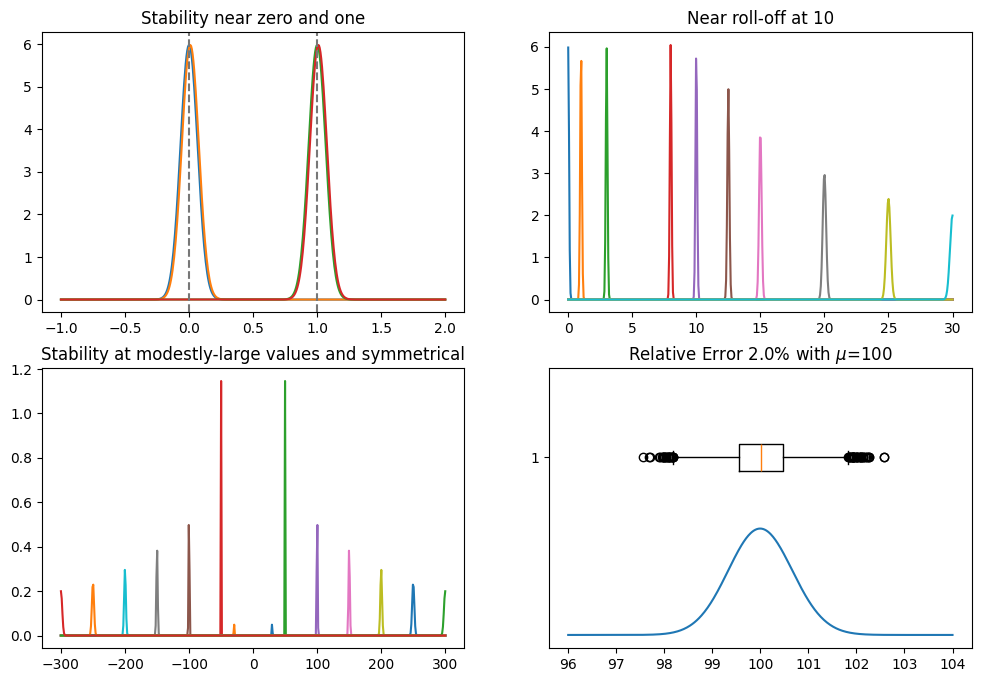

In [9]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import Distribution, constraints
from numpyro.distributions.util import promote_shapes

class SymmetricBlendedLogNormal(Distribution):
    arg_constraints = {
        "mu": constraints.real,
        "scale_neg": constraints.positive,
        "scale_norm": constraints.positive,
        "scale_pos": constraints.positive,
        "transition_rate": constraints.positive,
        "norm_dominance": constraints.real,
        "deadzone": constraints.positive,
    }
    
    support = constraints.real
    reparametrized_params = ["mu"]

    @classmethod
    def rolloff_relerr(cls, mu, rolloff, relerr, **kwargs):
        return cls(
            mu=mu,
            scale_neg=relerr / 3,
            scale_norm=rolloff * relerr / 3,
            scale_pos=relerr / 3,
            transition_rate=1.0,
            norm_dominance=rolloff,
            deadzone=rolloff / 10,
            **kwargs)
        
    def __init__(self, mu=0, scale_neg=.1, scale_norm=1.0, scale_pos=.1, 
                 transition_rate=1.0, norm_dominance=10.0, deadzone=1,
                 validate_args=None):
        
        # transition_rate dictates how sharply the mixture switches
        # norm_dominance dictates how wide the "normal" regime is around mu=0
        self.mu, self.scale_neg, self.scale_norm, self.scale_pos, \
        self.transition_rate, self.norm_dominance, self.deadzone = promote_shapes(
            mu, scale_neg, scale_norm, scale_pos, transition_rate, norm_dominance,
            deadzone,
        )
        
        batch_shape = jnp.shape(self.mu)
        super(SymmetricBlendedLogNormal, self).__init__(batch_shape=batch_shape, validate_args=validate_args)

    def _get_log_weights(self):
        # Create logits that shift dominance based on the sign and magnitude of mu
        logit_neg = jnp.where(
            -self.mu > self.deadzone,
            (-self.mu - self.deadzone) * self.transition_rate,
            -jnp.inf)
        logit_norm = self.norm_dominance * jnp.ones_like(self.mu)
        logit_pos = jnp.where(
            self.mu > self.deadzone,
            (self.mu - self.deadzone) * self.transition_rate,
            -jnp.inf)
        
        logits = jnp.stack([logit_neg, logit_norm, logit_pos], axis=-1)
        return jax.nn.log_softmax(logits, axis=-1)

    def sample(self, key, sample_shape=()):
        shape = sample_shape + self.batch_shape
        key_comp, key_neg, key_norm, key_pos = jrandom.split(key, 4)
        
        # 1. Sample which component is active based on weights
        log_weights = self._get_log_weights()
        comp = dist.Categorical(logits=log_weights).sample(key_comp, sample_shape)
        
        # 2. Setup the locs for the Log-Normal distributions
        # We add a tiny epsilon to avoid log(0) when mu is exactly 0
        safe_abs_mu = jnp.maximum(jnp.abs(self.mu), 1e-6)
        log_loc = jnp.log(safe_abs_mu)
        
        # 3. Sample from all three distributions
        samp_neg = -dist.LogNormal(log_loc, self.scale_neg).sample(key_neg, sample_shape)
        samp_norm = dist.Normal(self.mu, self.scale_norm).sample(key_norm, sample_shape)
        samp_pos = dist.LogNormal(log_loc, self.scale_pos).sample(key_pos, sample_shape)
        
        # 4. Pick the correct sample based on the categorical draw
        # comp == 0 -> neg, comp == 1 -> norm, comp == 2 -> pos
        return jnp.where(comp == 0, samp_neg, 
                 jnp.where(comp == 1, samp_norm, samp_pos))

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)
            
        log_weights = self._get_log_weights()
        
        safe_abs_mu = jnp.maximum(jnp.abs(self.mu), 1e-6)
        log_loc = jnp.log(safe_abs_mu)

        # --- SAFE EVALUATION TRICK ---
        # Provide strictly valid dummy values to the LogNormal log_prob to prevent NaNs.
        # The jnp.where mask will discard the dummy evaluations anyway.
        safe_val_for_neg = jnp.where(value < 0, -value, 1.0)
        safe_val_for_pos = jnp.where(value > 0, value, 1.0)

        # Component 0: Negative Log-Normal
        log_p_neg = jnp.where(
            value < 0, 
            dist.LogNormal(log_loc, self.scale_neg).log_prob(safe_val_for_neg), 
            -jnp.inf
        )
        
        # Component 1: Normal
        log_p_norm = dist.Normal(self.mu, self.scale_norm).log_prob(value)
        
        # Component 2: Positive Log-Normal
        log_p_pos = jnp.where(
            value > 0, 
            dist.LogNormal(log_loc, self.scale_pos).log_prob(safe_val_for_pos), 
            -jnp.inf
        )

        # Combine using logsumexp: log( w_neg*P_neg + w_norm*P_norm + w_pos*P_pos )
        components_log_prob = jnp.stack([
            log_weights[..., 0] + log_p_neg,
            log_weights[..., 1] + log_p_norm,
            log_weights[..., 2] + log_p_pos
        ], axis=-1)
        
        return jax.nn.logsumexp(components_log_prob, axis=-1)

import matplotlib.pyplot as plt
import numpy as np

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2, 2, figsize=[12, 8])
rolloff=10
relerr=0.02

x = np.linspace(-1, 2, 500)
for mu in [0, 0.01, 1, 1.01 ]:
    sbln = SymmetricBlendedLogNormal.rolloff_relerr(mu=mu, rolloff=rolloff, relerr=relerr)
    ax0.plot(x, np.exp(sbln.log_prob(x)))
ax0.axvline(0, ls='--', c='#777')
ax0.axvline(1, ls='--', c='#777')
ax0.set_title('Stability near zero and one')

x = np.linspace(0, 30, 500)
for mu in [0, 1, 3, 8, 10, 12.5, 15, 20, 25, 30]:
    sbln = SymmetricBlendedLogNormal.rolloff_relerr(mu=mu, rolloff=rolloff, relerr=relerr)
    ax1.plot(x, np.exp(sbln.log_prob(x)))
ax1.set_title(f'Near roll-off at {rolloff}')

x = np.linspace(-300, 300, 500)
for mu in [30, 50, 100, 150, 200, 250, 300]:
    sbln = SymmetricBlendedLogNormal.rolloff_relerr(mu=mu, rolloff=rolloff, relerr=relerr)
    ax2.plot(x, np.exp(sbln.log_prob(x)))
    
    sbln = SymmetricBlendedLogNormal.rolloff_relerr(mu=-mu, rolloff=rolloff, relerr=relerr)
    ax2.plot(x, np.exp(sbln.log_prob(x)))
ax2.set_title('Stability at modestly-large values and symmetrical')

x = np.linspace(100 * (1.0 - 2 * relerr), 100 * (1.0 + 2 * relerr), 500)
for mu in [100]:
    sbln = SymmetricBlendedLogNormal.rolloff_relerr(mu=mu, rolloff=rolloff, relerr=relerr)
    ax3.plot(x, np.exp(sbln.log_prob(x)))
    sample = sbln.sample(key=jrandom.key(123), sample_shape=(10000,))
    ax3.boxplot(sample, orientation='horizontal')
ax3.set_title(f'Relative Error {100 * relerr:.1f}% with $\mu$=100')
None